#  Импорт


In [ ]:
import numpy as np # библиотека Numpy для операций линейной алгебры и прочего
import pandas as pd # Библиотека Pandas для работы с табличными данными
import matplotlib.pyplot as plt # библиотека Matplotlib для визуализации
from matplotlib.colors import ListedColormap # функция библиотеки Matplotlib, которая генерирует цветовую карту

from sklearn.datasets import make_moons, make_circles, make_classification # генерируемые наборы данных


# Данные

Наши старые друзья / знакомые


In [ ]:
def plot_data(ax,ds,name='',marker = 'o',colors =("#FF0000", '#0000FF'),alpha=0.7, s = 150, facecolor=True):
    """Визуализация двумерных  данных для классификации
    Входные переменные:
    ===========
    ax: отдельная ячейка объекта figure
    ds: набор данных, содержащий признаки X и целевые метки y
    name: название графика
    marker: тип маркера - по умолчанию просто круги
    colors: цвета, которые будут использоваться для раскраски разных классов - по умолчанию Красный и Синий
    alpha: прозрачность маркеров
    s: размер маркера (~ квадрат радиуса)
    facecolor:
    """

    X, y = ds # распаковываем признаки и целевые метки в отдельные переменные

    cm_bright = ListedColormap(colors) # формируем цветовую карту из наших цветов
    ax.set_title(name, fontsize = 30) # прописываем название графика
    if facecolor: # если переменная задана, то просто рисуем скатерограмму по признакам с использованием параметров маркеров
        ax.scatter(X[:, 0], X[:, 1],
                   marker = marker, c=y,
                   cmap=cm_bright,s = s,
                   alpha =alpha)
    else: # иначе так же рисуем скатерограмму, но без
        ax.scatter(X[:, 0], X[:, 1],
                   marker = marker, c=y,
                   cmap=cm_bright,s = s,
                   facecolor = 'None',
                   alpha =alpha)
    # немного красоты и аккуратности
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5 # фиксируем минимальные и максимальные значения по горизонтали
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5 # фиксируем минимальные и максимальные значения по вертикали
    ax.grid(True)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())

In [ ]:
def make_binary_clf(N, method = 'line',
                    noises = 0.15,
                    random_state = 42,):
    """Создание синтетического набора данных
    для бинарной классификации
    Входные переменные:
    ===========
    N: количество точек
    method: тип набора данных
    noises: коэффициент ~ сила шума
    random_state: фиксированный сид случайных чисел (для повторяемости)
    """
    # фиксируем случайный seed
    if random_state: rng = np.random.RandomState(seed = random_state)

    if method == 'line' or method is None:
        # если выбран метод line (или никакой не задан)
        # то мы создаем набор данных с использованием функции make_classification
        # это будут линейно-разделимые данные
        X, y = make_classification(n_samples=N, # количество точек
                                   n_features=2, # количество признаков
                                   n_redundant=0, # количество бесполезных признаков
                                   n_informative=2,# количество информативных признаков
                                   n_clusters_per_class=1, # количество групп точек на класс
                                   class_sep=2, # количество классов
                                   random_state=random_state # фиксированный сид случайных чисел
                                   )
        X += np.random.randn(*X.shape) *noises # добавляем к признакам случайный шум

    elif method == 'moons':
        # если выбран метод moons
        # то мы создаем набор данных с использованием функции make_moons
        # это будут данные похожие на Инь-Ян
        X, y = make_moons(n_samples=N, # количество точек
                          noise=noises, # уровень шума
                          random_state=random_state # фиксированный сид случайных чисел
                          )

    elif method == 'circles':
        # если выбран метод circles
        # то мы создаем набор данных с использованием функции make_circles
        # это будут данные в виде концентрических окружностей
        X, y = make_circles(n_samples=N, # количество точек
                            noise=noises, # уровень шума
                            factor=0.5, # соотношение радиусов внуренней и внешней окружности
                            random_state=random_state # фиксированный сид случайных чисел
                            )


    return X,y

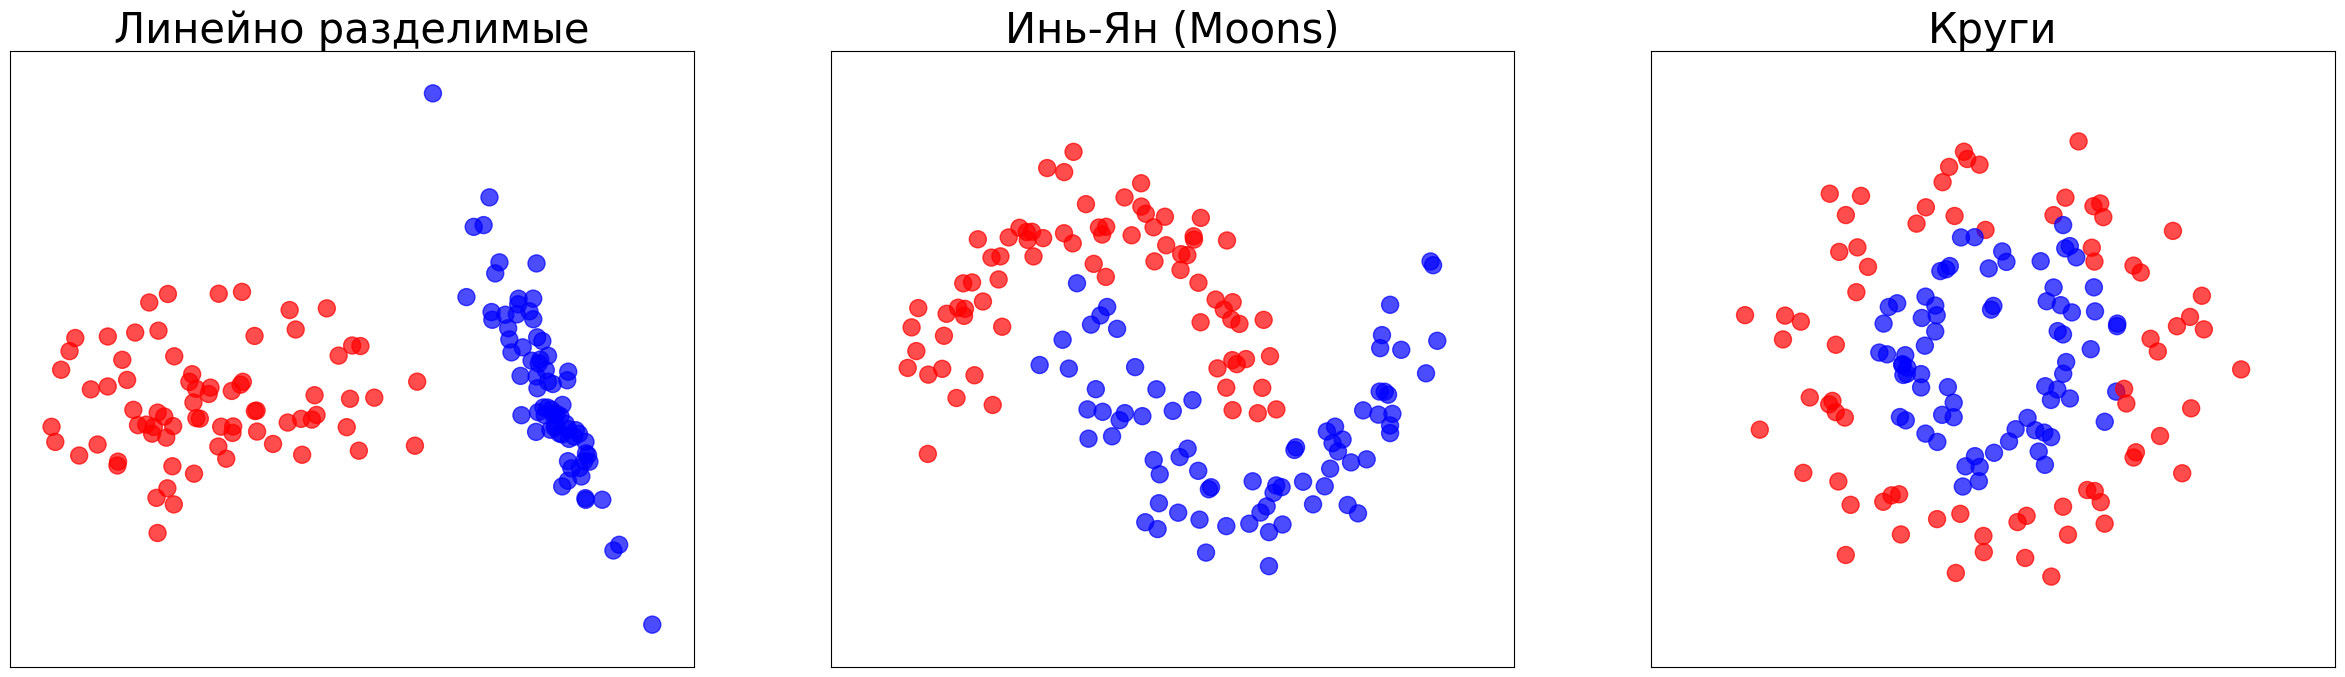

In [ ]:
#@title данные { run: "auto" }
N = 150 #@param {type:"slider", min:50, max:250, step:25}
noises = 0.15 #@param {type:"slider", min:0, max:1, step:0.05}

fig=plt.figure(figsize=(30,8))

ax = plt.subplot(1, 3, 1)
plot_data(ax,make_binary_clf(N,method = 'line',
                             noises = noises),
          'Линейно разделимые')
ax = plt.subplot(1, 3, 2)
plot_data(ax,make_binary_clf(N,method = 'moons',
                             noises = noises),
          'Инь-Ян (Moons)')
ax = plt.subplot(1, 3, 3)
plot_data(ax, make_binary_clf(N,method = 'circles',
                              noises = noises),
          'Круги')




За неимением лучшего аналога тестировать алгоритмы кластеризации будем на тех же наборах, что и классификацию

# Иерархическая Кластеризация

Начнем по традиции с простых данных - линейно разделимых

In [ ]:
N = 150
X,y = make_binary_clf(N,method = 'line', noises=0.05, )

X.shape

(150, 2)

In [ ]:
from sklearn.cluster import AgglomerativeClustering # Иерархическая Кластеризация от scikit-learn

По традиции мы сначала создаем объект нужного нам класса, в котором мы можем изменять гиперпараметры

В случае Иерархической кластеризации в основном меняем    
* `linkage` - тип связей (варианты  `'ward'`, `'average'`, `'complete'`, `'single'`)
* `n_clusters` - потенциальное число кластеров (на этапе анализа указываем `None`)
* `distance_threshold` - порог по расстоянию (на этапе анализа указываем `0`)



In [ ]:
#@markdown ### Выбираем тип связей
linkage = "ward" #@param [ 'ward', 'average', 'complete', 'single']{type:"string"}


# Создаем Класс Иерархической Кластеризации
hc = AgglomerativeClustering(distance_threshold=0,
                             n_clusters=None,
                             linkage=linkage)

hc

AgglomerativeClustering(distance_threshold=0, n_clusters=None)

Традиционно обучаем методом `.fit()`

In [ ]:
hc.fit(X);

Делаем предсказания - доступен `.fit_predict()` (т.е. **НЕЛЬЗЯ** подставлять новые данные)

Либо можем подсмотреть в атрибуте `.labels_`

In [ ]:
hc.labels_

array([137,  91, 141, 127,  85, 122, 128, 118, 140, 112, 142, 149,  79,
        83,  92, 135, 136, 134,  80, 110, 133,  96,  99, 132,  77, 107,
       115, 116, 143, 104, 139, 103,  57, 121, 123, 131,  60, 129,  93,
        67,  89, 126,  95,  97, 117,  45, 106,  98,  81,  86, 105,  78,
        47, 144, 130,  63, 125, 102, 147, 114, 124,  69, 113, 111,  52,
        51, 148,  73,  56, 145, 138,  82, 109,  64, 100,  54,  74, 108,
        58, 120,  38,  90,  65,  84,  76,  41,  39, 101,  70,  34,  48,
        50,  53,  61,  75,  68,  33,  55,  88,  71,  62,  44, 146,  16,
        30,  28,  72,  27,  37,  40, 119,  26,  87,  66,  94,  35,  31,
        43,  32,  42,  59,  15,   7,  46,  36,  19,  23,  17,  21,  18,
        13,  49,  29,  25,  12,  14,  20,   8,   9,   3,  24,   6,  22,
        10,  11,   5,   4,   1,   2,   0])

In [ ]:
hc.fit_predict(X)

array([137,  91, 141, 127,  85, 122, 128, 118, 140, 112, 142, 149,  79,
        83,  92, 135, 136, 134,  80, 110, 133,  96,  99, 132,  77, 107,
       115, 116, 143, 104, 139, 103,  57, 121, 123, 131,  60, 129,  93,
        67,  89, 126,  95,  97, 117,  45, 106,  98,  81,  86, 105,  78,
        47, 144, 130,  63, 125, 102, 147, 114, 124,  69, 113, 111,  52,
        51, 148,  73,  56, 145, 138,  82, 109,  64, 100,  54,  74, 108,
        58, 120,  38,  90,  65,  84,  76,  41,  39, 101,  70,  34,  48,
        50,  53,  61,  75,  68,  33,  55,  88,  71,  62,  44, 146,  16,
        30,  28,  72,  27,  37,  40, 119,  26,  87,  66,  94,  35,  31,
        43,  32,  42,  59,  15,   7,  46,  36,  19,  23,  17,  21,  18,
        13,  49,  29,  25,  12,  14,  20,   8,   9,   3,  24,   6,  22,
        10,  11,   5,   4,   1,   2,   0])

Обращаем ваше внимание, что сейчас нет порога по расстоянию и нет отсечения по количеству кластеров

Поэтому алгоритм считает каждую точку отдельным кластером

Запишем функцию для визуализации результатов кластеризации

In [ ]:
def plot_clustering(X, hc):
    """Визуализация результатов кластеризации
    Входные переменные:
    ===========
    X: данные, на которых мы хотим построить визуализацию
    hc: обученный класс Иерархической кластеризации
    """
    labels = hc.fit_predict(X) # предсказываем метки кластеров
    ax = plt.subplot(1, 1, 1) # создаем полотно
    # отрисовываем скатерограмму
    ax.scatter(X[:, 0], X[:, 1], # данные
                    c=labels,  # подкрашиваем по предсказанным меткам
                    alpha = 0.75, # прозрачность
                    cmap = 'bwr', # тип цветовой карты
                    edgecolor = 'k', # цвет края - черный
                    s = 100  # размер
               )
    plt.xticks([],[])
    plt.yticks([],[])

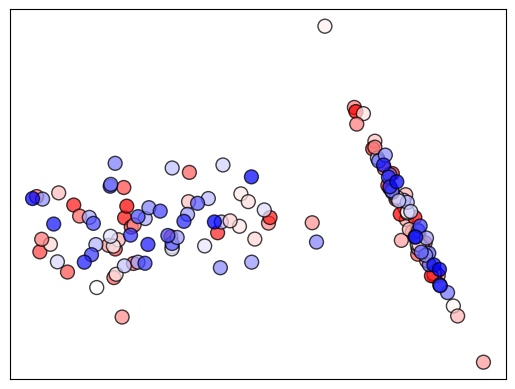

In [ ]:
plot_clustering(X, hc)

В цветовой карте 'bwr' (как и в любой другой) не бесконечное число возможных цветов

Поэтому некоторые точки окрашиваются в один и тот же цвет, несмотря на то, что метки разные

Функция для отрисовки дендрограммы (будет работать только после того как сделан `fit` )

In [ ]:
def plot_dendrogram(model,write_split, **kwargs):
    from scipy.cluster.hierarchy import dendrogram # дендрограмма от библиотеки Scipy

    # Считаем количество объектов в "конце" дендрограммы
    # для этого анализируем всех "детей"
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    # подготавливаем данные для функции дендрограммы
    # указываем всех детей, расстояния и наш счетчик
    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)

    # строим соответствующую дендрограмму (она сразу визуализирует)
    ddata = dendrogram(linkage_matrix, **kwargs)

    plt.title('Дендрограмма иерархической кластеризации')
    plt.xlabel('индекс образца или (размер кластера)')
    plt.ylabel('расстояние')
    # добавим "изюминок" - точек разделения с подписями значений расстояния на разбиении
    for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
        x = 0.5 * sum(i[1:3])
        y = d[1]
        if y > write_split:
            plt.plot(x, y, 'o', c=c)
            plt.annotate("%.3g" % y, (x, y), xytext=(0, -5),
                          textcoords='offset points',
                          va='top', ha='center')

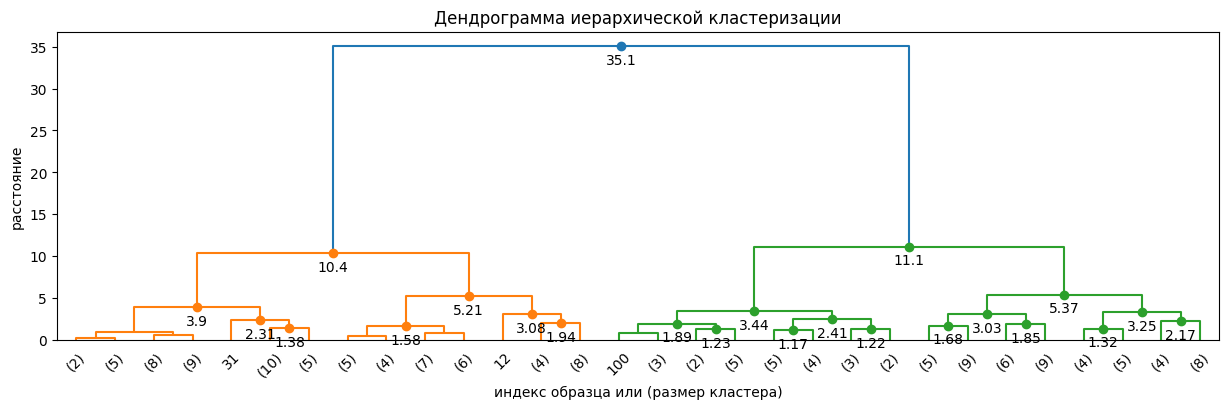

In [ ]:
plt.figure(figsize=(15,4))
plot_dendrogram(hc,write_split=1, truncate_mode='level', p=4)

Когда у нас есть дендрограмма, можно принимать решениеи о кластеризации с использованием порога по расстоянию

и тут слегка модифицированный "паттерн" применения

1. Создаем объект, в котором можем менять гиперпараметры

* `linkage` - берем тот же что и был при построения дендрограммы
* `n_clusters` - потенциальное число кластеров (в целом лучше указывать `None`)
* `distance_threshold` - порог по расстоянию (из анализа дедрограммы)

2. Традиционно обучаем методом `.fit()` (указываем только `X` - это же обучение без учителя)

3. Делаем предсказания - доступен `.fit_predict()` (т.е. **НЕЛЬЗЯ** подставлять новые данные)

4. Анализируем результат (в этом случае предлагается визуализация с подсцветкой)

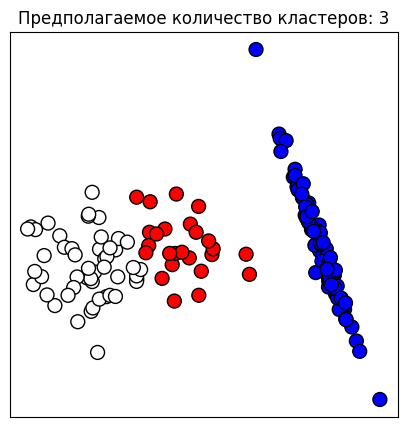

In [ ]:
#@title Distance Threshold { run: "auto" }
#@markdown Можно писать число
dt = 11 #@param {type:"number"}


# создаем объект
hc = AgglomerativeClustering(distance_threshold=dt,
                                n_clusters=None,
                                linkage=linkage)
# обучаем на данных
hc = hc.fit(X)

# предсказываем метки кластеров для данных
labels=hc.fit_predict(X)

# визуализируем с подкрашиванием
plt.figure(figsize=(5,5))
plt.scatter(X[:, 0], X[:, 1], cmap = 'bwr',
            c=labels, edgecolors = 'k',
             s=100)

n_clusters_ = hc.n_clusters_
plt.title('Предполагаемое количество кластеров: %d' % n_clusters_)
plt.xticks([],[])
plt.yticks([],[])
plt.grid()

# Задание

Проверить алгоритм Иерархической Кластеризации на данных Инь-Ян  и Круги

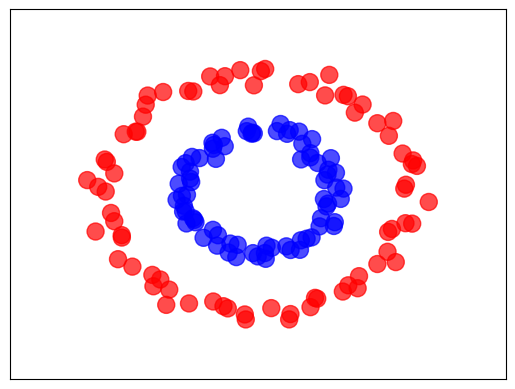

In [ ]:
N = 150
X_circle,y_circle = make_binary_clf(N,method = 'circles', noises=0.05, )
ax = plt.subplot(1, 1, 1)
plot_data(ax,(X_circle,y_circle))

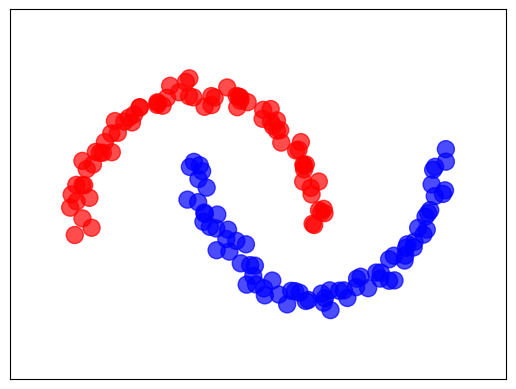

In [ ]:
N = 150
X_moons,y_moons = make_binary_clf(N,method = 'moons', noises=0.05, )
ax = plt.subplot(1, 1, 1)
plot_data(ax,(X_moons,y_moons))